###### Data Unboxed — DAV Masterclass
###### Telecom Customer Churn Analysis
| Module | Topic |
|--------|-------|
| 02 | Data Collection & Loading |
| 03 | Data Cleaning & Preprocessing |
| 04 & 05 | EDA & Visualization |
| 08 | Bridge to Machine Learning |
> **Question:** A telecom company is losing customers. Can data tell us *who* is leaving and *why*?

#### Why this cell:
Load all tools we'll need up front — pandas for tables, numpy for numeric operations, matplotlib/seaborn for charts. `sns.set_theme(...)` makes every chart look consistent for the rest of the notebook, purely cosmetic. Nothing analytical happens here yet — this is just opening our toolbox.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style='whitegrid', palette='Set2')
print("Libraries loaded!")

Libraries loaded!



##### Module 02: Data Collection & Loading

#### Why this cell:
Before touching the data, we load it and immediately check its size (shape). This answers the first analytical question every analyst should ask: "How much data am I working with?" Rows = number of customers, Columns = number of features recorded per customer.

In [36]:
# Load the dataset
df = pd.read_csv('CustomerChurn.csv')
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 7043
Columns : 21


#### Why this cell:
`.head()` gives a visual first look at the raw data — actual column names and sample values. This is where you eyeball things like 'oh, TotalCharges looks numeric but let\'s confirm' or 'Churn is stored as Yes/No text, not 0/1.'

In [37]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### Why this cell:
`.info()` tells us the data type of every column and whether any have missing entries (via non-null counts). This is the key diagnostic step — it's how we'll first spot that TotalCharges is wrongly typed as object (text) instead of a number, even though it's not obviously missing anything yet.

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### Why this cell:
`.describe()` summarizes only the numeric columns — mean, min, max, quartiles. Use it to sanity-check the data: does tenure range from 0–72 months (makes sense)? Are there impossible values (e.g. negative charges)? This is a quick red-flag check before deeper analysis.

In [39]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


---
##### 🧹 Module 03: Data Cleaning & Preprocessing


#### Why this cell:
`customerID` is a unique label for each row — it carries no predictive signal about why someone churns, so we drop it early to avoid noise. This is a cleaning decision, not a data-loss risk, since it doesn't correlate with the outcome.

In [40]:
df.drop(columns=['customerID'], inplace=True)
df.shape

(7043, 20)


#### Step 2 — Fix `TotalCharges` (Object → Float)


#### Why this cell:
`TotalCharges` looked numeric in `.head()` but was typed as text in `.info()` — a classic real-world data trap, usually caused by blank/space characters hiding inside a numeric-looking column. `pd.to_numeric(..., errors='coerce')` forces conversion and turns any unconvertible value into NaN, which we can now count and see.

In [41]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


#### Why this cell:
Now that the invalid entries in `TotalCharges` are visible as NaN, we need to decide how to handle them. Filled with 0 here — reasonable because missing TotalCharges usually means brand-new customers with 0 tenure, so 0 total billed makes domain sense. The follow-up `isnull().sum().sum()` confirms no missing values remain anywhere in the dataset.

In [42]:
df['TotalCharges'].fillna(0, inplace=True)
print("Missing values:", df.isnull().sum().sum())

Missing values: 0


/tmp/ipykernel_925/2099018138.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


#### Why this cell:
Before any modeling, we look at the target variable itself — how many customers churned vs. stayed. This single line answers a critical question: is this a balanced problem, or a skewed one? That answer affects how we evaluate any future model (plain accuracy is misleading on imbalanced data).

In [44]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


#### Why this cell:
Before any modeling, we look at the target variable itself — how many customers churned vs. stayed. This single line answers a critical question: is this a balanced problem, or a skewed one? That answer affects how we evaluate any future model (plain accuracy is misleading on imbalanced data).

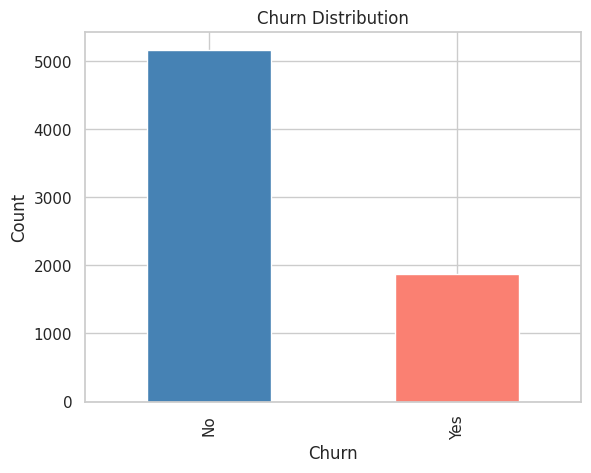

In [45]:
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

#### Why this cell:
This moves from describing the data to asking a question of it: does contract type relate to churn? Splitting the bars by `hue='Churn'` lets us visually compare churn rates across Month-to-month, One year, and Two year contracts — this is where EDA turns into a business insight, not just a chart.

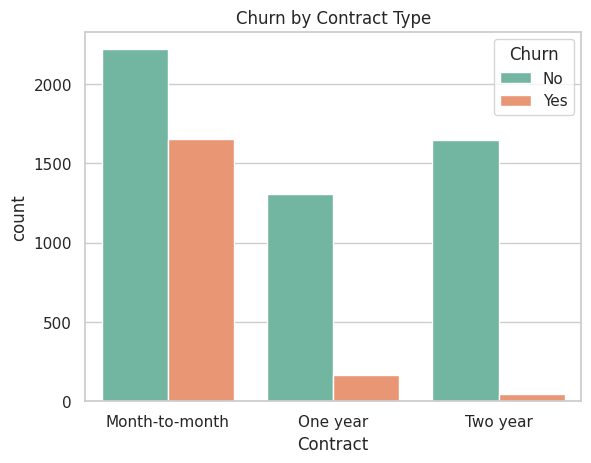

In [46]:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.show()

#### Why this cell:
Same idea as the contract chart, but for a numeric feature. Overlapping histograms of tenure for churned vs. stayed customers show where churn concentrates (usually at low tenure). The printed averages back up the visual with an exact number — always pair a chart with the number it illustrates.

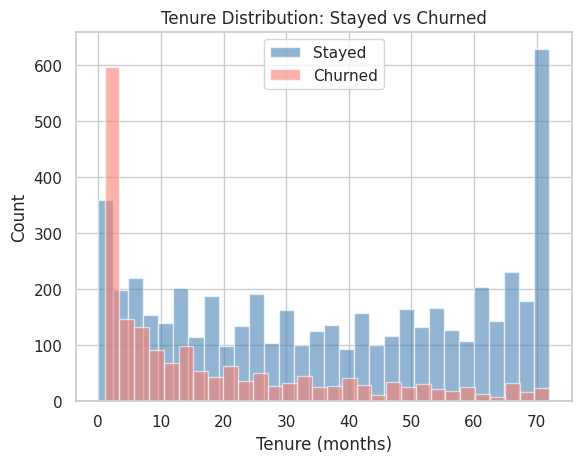

Avg tenure - Stayed : 37.6 months
Avg tenure - Churned: 18.0 months


In [47]:
churned     = df[df['Churn'] == 'Yes']['tenure']
not_churned = df[df['Churn'] == 'No']['tenure']
plt.hist(not_churned, bins=30, alpha=0.6, label='Stayed', color='steelblue')
plt.hist(churned,     bins=30, alpha=0.6, label='Churned', color='salmon')
plt.title('Tenure Distribution: Stayed vs Churned')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.legend()
plt.show()
print("Avg tenure - Stayed :", round(not_churned.mean(), 1), "months")
print("Avg tenure - Churned:", round(churned.mean(), 1), "months")

#### Why this cell:
A correlation heatmap checks how the numeric features move together. This matters for two reasons: (1) spotting redundant features that carry overlapping information, and (2) getting an early hint of which numeric features might matter most to churn before any model is built.

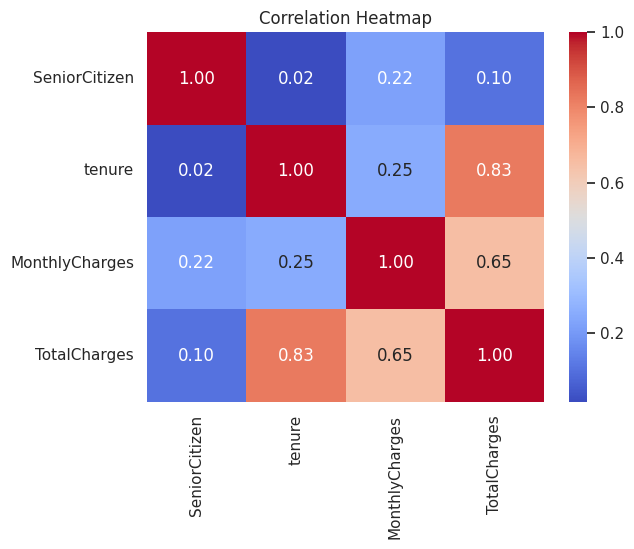

In [48]:
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#### Why this cell:
Machine learning models need numbers, not text like "Yes"/"No". `LabelEncoder` converts simple two-category (binary) columns into 0/1. Applied only to columns with exactly two categories — for 3+ categories, label-encoding would wrongly imply a ranking, so the next cell handles those differently with one-hot encoding.

In [64]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()
le = LabelEncoder()

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

df_ml[['Partner', 'Churn']].head(3)


,Partner,Churn
0,1,0
1,0,0
2,0,1


#### Why this cell:
For columns with more than two categories — `Contract`, `InternetService`, `PaymentMethod` — `pd.get_dummies` creates a separate 0/1 column for each category instead of assigning a single number. This prevents the model from falsely treating the categories as ranked or ordered. `drop_first=True` drops one column per group since it is already implied by the others.

In [65]:
df_ml = pd.get_dummies(df_ml,
                       columns=['Contract', 'InternetService', 'PaymentMethod'],
                       drop_first=True)

print("Before encoding:", df.shape)
print("After encoding :", df_ml.shape)
print("Data is now fully numeric — ready for ML!")


Before encoding: (7043, 20)
After encoding : (7043, 24)
Data is now fully numeric — ready for ML!
